In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.schema import Trade
from src.policy.ground_truth import get_relevant_policies
from src.policy.retrieval import retrieve_policies
from src.decisioning.retrieval_prediction import predict_with_retrieval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Section 1: Load dataset

In [2]:
df = pd.read_csv("./outputs/data_with_predictions_20260501_113538.csv")
display(df.head())

,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,...,difficulty,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,has_conflicting_signals,conflict_signals,risk_bucket
0,TRADE-00f1841e,2026-04-03 02:12:40.508128,22,32353,High,Advanced,Balanced,Medium,Mutual Funds,11797.57,...,Hard,1.0,True,25,0.650,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low
1,TRADE-abf503b3,2026-04-20 01:25:37.442634,44,160619,Low,Intermediate,Growth,Long,T-Bills,3440.32,...,Hard,1.0,True,20,0.770,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low
2,TRADE-ac545ce6,2026-04-14 23:02:03.389634,79,100590,Low,Advanced,Preservation,Long,Mutual Funds,64830.06,...,Hard,1.0,True,25,0.730,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low
3,TRADE-9d14f6b2,2026-04-14 21:28:28.231661,69,90968,Medium,Advanced,Balanced,Long,ETFs,77419.19,...,Easy,1.0,False,55,0.645,urgent,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Medium
4,TRADE-23c79acf,2026-04-18 01:13:34.672944,80,135652,Low,Beginner,Preservation,Short,Bonds,72419.91,...,Hard,1.0,True,25,0.610,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low


## Section 2: Get relevant and retrieved policies

In [3]:
df["advisor_notes"] = df["advisor_notes"].fillna("")

results = []

for _, row in df.iterrows():
    trade = Trade(**row.to_dict())

    relevant = get_relevant_policies(trade)
    retrieved = retrieve_policies(trade)

    results.append({
        "trade_id": trade.trade_id,
        "relevant_policies": relevant,
        "retrieved_policies": retrieved
    })

policies_df = pd.DataFrame(results)

df = df.merge(policies_df, on="trade_id")
display(df.head())

,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,...,compliance_label,risk_score,confidence_score,escalation_level,priority_score,has_conflicting_signals,conflict_signals,risk_bucket,relevant_policies,retrieved_policies
0,TRADE-00f1841e,2026-04-03 02:12:40.508128,22,32353,High,Advanced,Balanced,Medium,Mutual Funds,11797.57,...,True,25,0.650,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_KYC_002, POLICY_RISK_001]",[POLICY_RISK_001]
1,TRADE-abf503b3,2026-04-20 01:25:37.442634,44,160619,Low,Intermediate,Growth,Long,T-Bills,3440.32,...,True,20,0.770,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,[POLICY_KYC_002],"[POLICY_SUIT_001, POLICY_KYC_002]"
2,TRADE-ac545ce6,2026-04-14 23:02:03.389634,79,100590,Low,Advanced,Preservation,Long,Mutual Funds,64830.06,...,True,25,0.730,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_RISK_001, POLICY_SUP_001]","[POLICY_SUP_001, POLICY_SUIT_001, POLICY_SUIT_..."
3,TRADE-9d14f6b2,2026-04-14 21:28:28.231661,69,90968,Medium,Advanced,Balanced,Long,ETFs,77419.19,...,False,55,0.645,urgent,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Medium,"[POLICY_KYC_001, POLICY_RISK_001, POLICY_DOC_001]","[POLICY_DOC_001, POLICY_RISK_001]"
4,TRADE-23c79acf,2026-04-18 01:13:34.672944,80,135652,Low,Beginner,Preservation,Short,Bonds,72419.91,...,True,25,0.610,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_KYC_002, POLICY_RISK_001, POLICY_DOC_001]","[POLICY_SUIT_001, POLICY_SUIT_003, POLICY_SUIT..."


## Section 3: Compute per-case metrics

In [4]:
def compute_precision(row: pd.Series) -> float:
    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])
    if len(retrieved) == 0:
        return 1.0 if len(relevant) == 0 else 0.0
    return len(relevant.intersection(retrieved)) / len(retrieved)

def compute_recall(row: pd.Series) -> float:
    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])
    if len(relevant) == 0:
        return 1.0
    return len(relevant.intersection(retrieved)) / len(relevant)

df["precision"] = df.apply(compute_precision, axis=1)
df["recall"] = df.apply(compute_recall, axis=1)

display(df.head())

,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,...,confidence_score,escalation_level,priority_score,has_conflicting_signals,conflict_signals,risk_bucket,relevant_policies,retrieved_policies,precision,recall
0,TRADE-00f1841e,2026-04-03 02:12:40.508128,22,32353,High,Advanced,Balanced,Medium,Mutual Funds,11797.57,...,0.650,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_KYC_002, POLICY_RISK_001]",[POLICY_RISK_001],1.000000,0.500000
1,TRADE-abf503b3,2026-04-20 01:25:37.442634,44,160619,Low,Intermediate,Growth,Long,T-Bills,3440.32,...,0.770,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,[POLICY_KYC_002],"[POLICY_SUIT_001, POLICY_KYC_002]",0.500000,1.000000
2,TRADE-ac545ce6,2026-04-14 23:02:03.389634,79,100590,Low,Advanced,Preservation,Long,Mutual Funds,64830.06,...,0.730,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_RISK_001, POLICY_SUP_001]","[POLICY_SUP_001, POLICY_SUIT_001, POLICY_SUIT_...",0.500000,1.000000
3,TRADE-9d14f6b2,2026-04-14 21:28:28.231661,69,90968,Medium,Advanced,Balanced,Long,ETFs,77419.19,...,0.645,urgent,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Medium,"[POLICY_KYC_001, POLICY_RISK_001, POLICY_DOC_001]","[POLICY_DOC_001, POLICY_RISK_001]",1.000000,0.666667
4,TRADE-23c79acf,2026-04-18 01:13:34.672944,80,135652,Low,Beginner,Preservation,Short,Bonds,72419.91,...,0.610,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_KYC_002, POLICY_RISK_001, POLICY_DOC_001]","[POLICY_SUIT_001, POLICY_SUIT_003, POLICY_SUIT...",0.333333,0.666667


## Section 4: Calculate context sufficiency

In [5]:
def is_context_sufficient(row: pd.Series) -> bool:
    relevant_policies = set(row["relevant_policies"])
    retrieved_policies = set(row["retrieved_policies"])
    return relevant_policies.issubset(retrieved_policies)

df["context_sufficient"] = df.apply(is_context_sufficient, axis=1)
display(df.head())

,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,...,escalation_level,priority_score,has_conflicting_signals,conflict_signals,risk_bucket,relevant_policies,retrieved_policies,precision,recall,context_sufficient
0,TRADE-00f1841e,2026-04-03 02:12:40.508128,22,32353,High,Advanced,Balanced,Medium,Mutual Funds,11797.57,...,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_KYC_002, POLICY_RISK_001]",[POLICY_RISK_001],1.000000,0.500000,False
1,TRADE-abf503b3,2026-04-20 01:25:37.442634,44,160619,Low,Intermediate,Growth,Long,T-Bills,3440.32,...,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,[POLICY_KYC_002],"[POLICY_SUIT_001, POLICY_KYC_002]",0.500000,1.000000,True
2,TRADE-ac545ce6,2026-04-14 23:02:03.389634,79,100590,Low,Advanced,Preservation,Long,Mutual Funds,64830.06,...,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_RISK_001, POLICY_SUP_001]","[POLICY_SUP_001, POLICY_SUIT_001, POLICY_SUIT_...",0.500000,1.000000,True
3,TRADE-9d14f6b2,2026-04-14 21:28:28.231661,69,90968,Medium,Advanced,Balanced,Long,ETFs,77419.19,...,urgent,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Medium,"[POLICY_KYC_001, POLICY_RISK_001, POLICY_DOC_001]","[POLICY_DOC_001, POLICY_RISK_001]",1.000000,0.666667,False
4,TRADE-23c79acf,2026-04-18 01:13:34.672944,80,135652,Low,Beginner,Preservation,Short,Bonds,72419.91,...,none,NaN,False,"{'risk_too_high_for_profile': False, 'too_comp...",Low,"[POLICY_KYC_002, POLICY_RISK_001, POLICY_DOC_001]","[POLICY_SUIT_001, POLICY_SUIT_003, POLICY_SUIT...",0.333333,0.666667,False


## Section 5: Aggregate metrics & summary statistics

In [23]:
print(f"Average Precision: {df['precision'].mean():.2f}")
print(f"Average Recall: {df['recall'].mean():.2f}")
print(f"Context Sufficiency rate: {df['context_sufficient'].mean():.2f}")

df.describe()

Average Precision: 0.58
Average Recall: 0.82
Context Sufficiency rate: 0.69


,client_age,client_income,investment_amount,compliance_probability,risk_score,confidence_score,priority_score,precision,recall,compliance_probability_with_retrieval,num_relevant
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,80.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,48.511000,113711.731000,50455.935610,0.871300,24.410000,0.733165,132.130000,0.575324,0.824150,0.877500,1.886000
std,17.905823,49819.775938,28729.713277,0.262212,19.812734,0.082326,37.456041,0.349463,0.302133,0.259482,1.127952
min,18.000000,30099.000000,371.860000,0.000000,0.000000,0.580000,33.600000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,70505.000000,26189.542500,1.000000,15.000000,0.670000,141.375000,0.333333,0.666667,1.000000,1.000000
50%,48.000000,112289.500000,50136.065000,1.000000,20.000000,0.730000,142.850000,0.500000,1.000000,1.000000,2.000000
75%,63.000000,158321.500000,74499.207500,1.000000,30.000000,0.790000,149.850000,1.000000,1.000000,1.000000,3.000000
max,80.000000,199996.000000,99850.200000,1.000000,100.000000,0.940000,162.750000,1.000000,1.000000,1.000000,6.000000


## Section 6: Graphs

### Precision vs Recall Scatter Plot

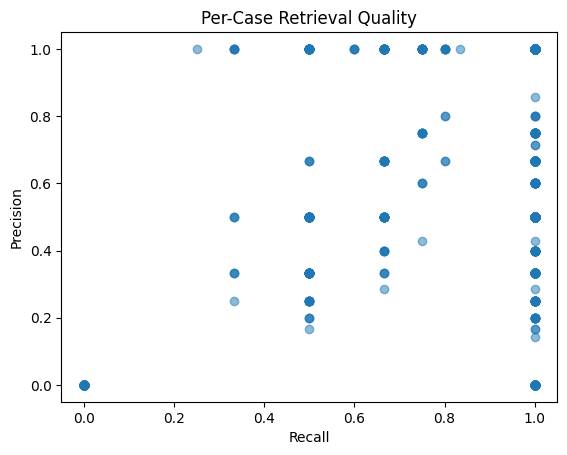

In [7]:

plt.scatter(df["recall"], df["precision"], alpha=0.5)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Per-Case Retrieval Quality")
plt.show()

There's a positive correlation between precision and recall, caused by the retrieval function design as a noisy, probabilistic approximation of the ground truth mapping function where policies are **independently** (probabilistically) added and missed. This is in contrast to a classical precision-recall tradeoff relationship where extra additions or misses wouldn't vary independently but have a negative correlation.

### Distribution histograms

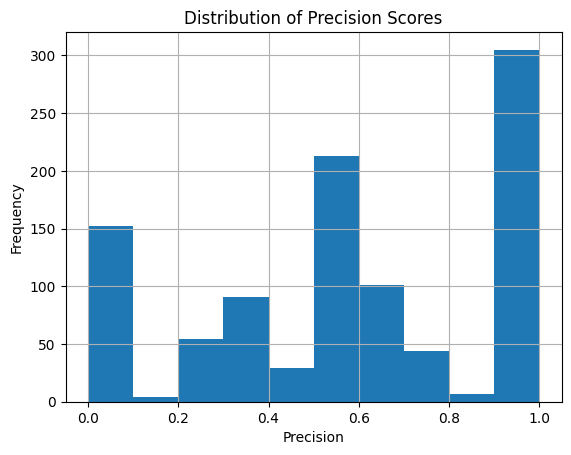

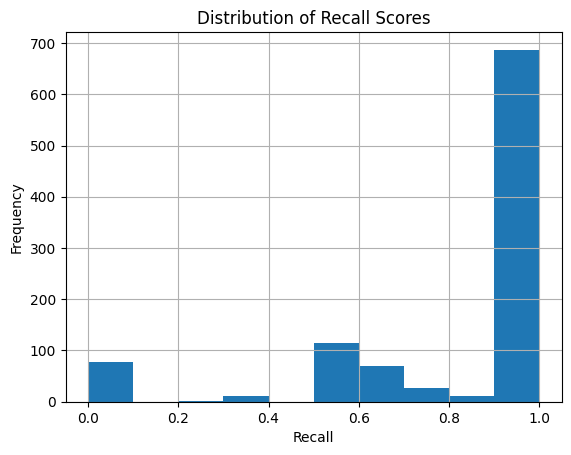

In [8]:
df["precision"].hist()
plt.title("Distribution of Precision Scores")
plt.xlabel("Precision")
plt.ylabel("Frequency")
plt.show()

df["recall"].hist()
plt.title("Distribution of Recall Scores")
plt.xlabel("Recall")
plt.ylabel("Frequency")
plt.show()

### Context sufficiency rate

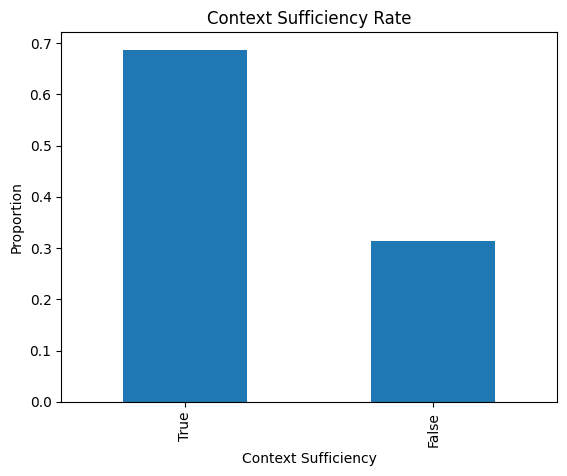

In [9]:
df["context_sufficient"].value_counts(normalize=True).plot(kind="bar")
plt.title("Context Sufficiency Rate")
plt.xlabel("Context Sufficiency")
plt.ylabel("Proportion")
plt.show()

### Retrieval vs difficulty

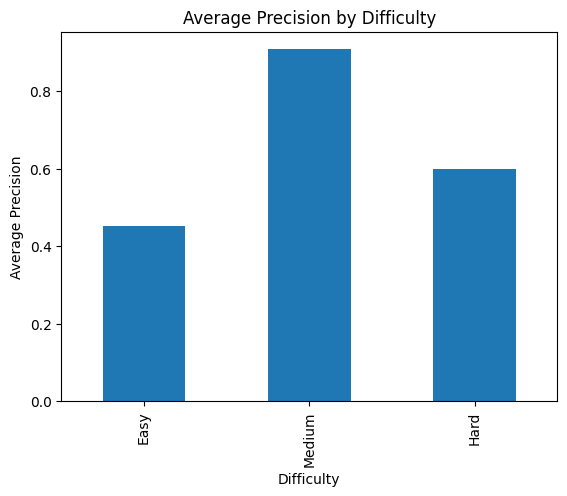

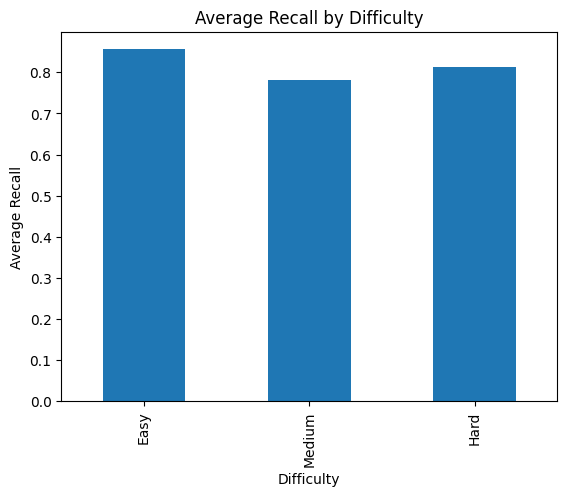

In [10]:
order = ["Easy", "Medium", "Hard"]

stats = df.groupby("difficulty")["precision"].mean().reindex(order)
stats.plot(kind="bar")
plt.title("Average Precision by Difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Average Precision")
plt.show()

stats = df.groupby("difficulty")["recall"].mean().reindex(order)
stats.plot(kind="bar")
plt.title("Average Recall by Difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Average Recall")
plt.show()

## Section 7: Get compliance predictions and compare with ground truth

In [11]:
predicted_results = []

for _, row in df.iterrows():
    trade = Trade(**row.to_dict())
    retrieved_policies = row["retrieved_policies"]
    
    predicted_result = predict_with_retrieval(trade, retrieved_policies)
    predicted_results.append({
        "trade_id": trade.trade_id,
        "compliance_label_with_retrieval": predicted_result["compliance_label"],
        "compliance_probability_with_retrieval": predicted_result["compliance_probability"]
    })

compliance_predictions_df = pd.DataFrame(predicted_results)
df = df.merge(compliance_predictions_df, on="trade_id")

In [12]:
df["error_compliance_prediction_with_retrieval"] = df["compliance_label_with_retrieval"] != df["true_compliance"]
#display(df.head())
display(df[["trade_id", "recall", "precision", "context_sufficient", "compliance_label_with_retrieval", "true_compliance", "error_compliance_prediction_with_retrieval"]])

,trade_id,recall,precision,context_sufficient,compliance_label_with_retrieval,true_compliance,error_compliance_prediction_with_retrieval
0,TRADE-00f1841e,0.500000,1.000000,False,True,True,False
1,TRADE-abf503b3,1.000000,0.500000,True,True,True,False
2,TRADE-ac545ce6,1.000000,0.500000,True,True,True,False
3,TRADE-9d14f6b2,0.666667,1.000000,False,True,False,True
4,TRADE-23c79acf,0.666667,0.333333,False,True,True,False
...,...,...,...,...,...,...,...
995,TRADE-9289bb40,1.000000,1.000000,True,True,True,False
996,TRADE-33a378a9,1.000000,0.750000,True,True,True,False
997,TRADE-f3717858,1.000000,0.500000,True,False,True,True
998,TRADE-8f86b0c3,1.000000,1.000000,True,True,True,False


## Section 8: Analyze results

### Error rate vs retrieval recall

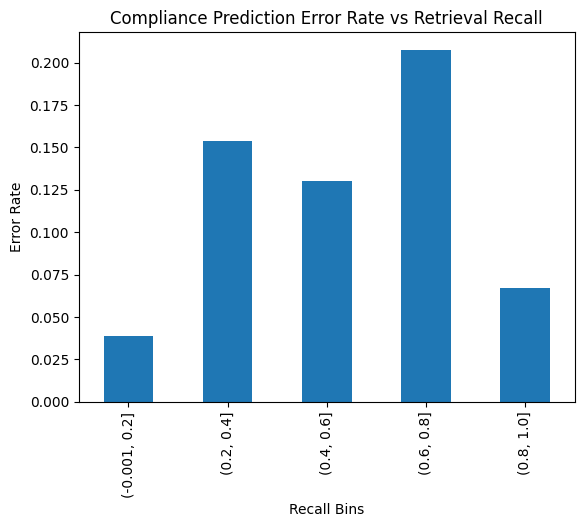

In [13]:
df["recall_bins"] = pd.cut(df["recall"], bins=5)
recall_error = df.groupby("recall_bins")["error_compliance_prediction_with_retrieval"].mean()
recall_error.plot(kind="bar")
plt.title("Compliance Prediction Error Rate vs Retrieval Recall")
plt.xlabel("Recall Bins")
plt.ylabel("Error Rate")
plt.show()

In the graph above, the erratic appearance of error rate vs retrieval recall may be due to several factors:
- Small / uneven sample sizes per bin
- Different case types with different sensitivity to recall being mixed together (e.g. KYC violations --> high impact, suitability mismatches --> lesser impact)
- Recall doesn't account for policy importance in compliance determination

Let's do some checks:

recall_bins
(-0.001, 0.2]     78
(0.2, 0.4]        13
(0.4, 0.6]       115
(0.6, 0.8]       106
(0.8, 1.0]       688
dtype: int64


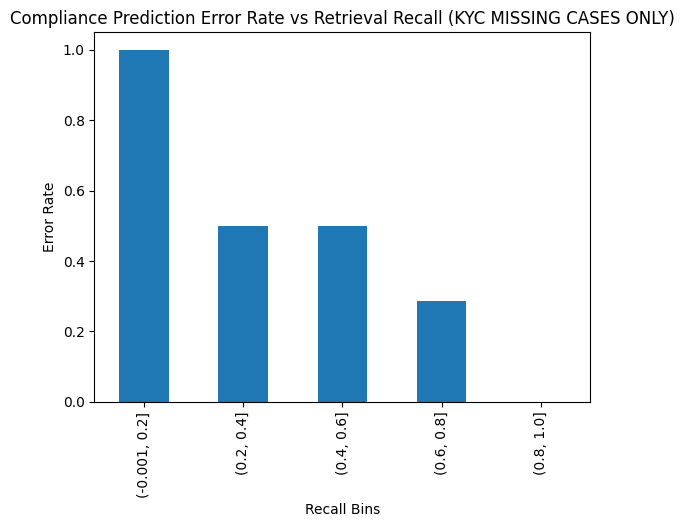

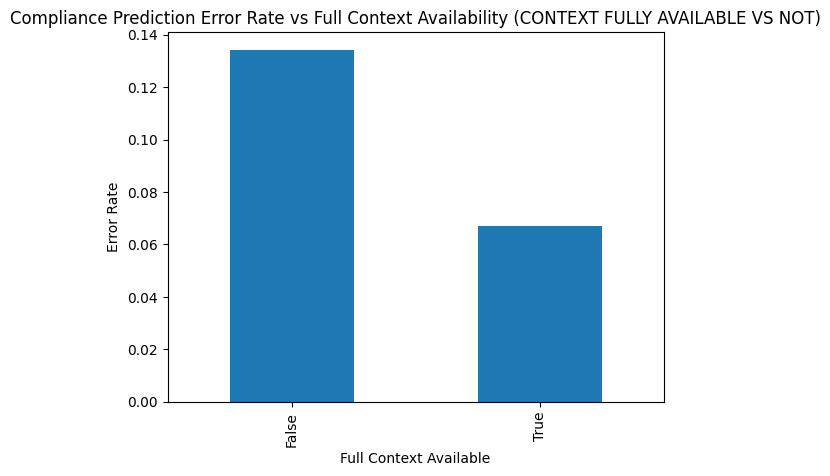

critical_policy_missing
False    0.07996
True     0.75000
Name: error_compliance_prediction_with_retrieval, dtype: float64

In [14]:
# Check bin sizes
print(df.groupby("recall_bins").size())

# Analyze KYC missing cases separately
df_kyc = df[df["relevant_policies"].apply(lambda x: "POLICY_KYC_001" in x)]
df_kyc["recall_bins"] = pd.cut(df_kyc["recall"], bins=5)
recall_error = df_kyc.groupby("recall_bins")["error_compliance_prediction_with_retrieval"].mean()
recall_error.plot(kind="bar")
plt.title("Compliance Prediction Error Rate vs Retrieval Recall (KYC MISSING CASES ONLY)")
plt.xlabel("Recall Bins")
plt.ylabel("Error Rate")
plt.show()

# Analyze error rate where recall is perfect vs not
df["full_context"] = df.apply(
    lambda row: set(row["relevant_policies"]).issubset(set(row["retrieved_policies"])),
    axis=1
)
full_context_error = df.groupby("full_context")["error_compliance_prediction_with_retrieval"].mean()
full_context_error.plot(kind="bar")
plt.title("Compliance Prediction Error Rate vs Full Context Availability (CONTEXT FULLY AVAILABLE VS NOT)")
plt.xlabel("Full Context Available")
plt.ylabel("Error Rate")
plt.show()

# Check error rate for cases where a critical policy is missing vs not
def critical_policy_missing(row):
    return (
        "POLICY_KYC_001" in row["relevant_policies"]
        and "POLICY_KYC_001" not in row["retrieved_policies"]
    )
df["critical_policy_missing"] = df.apply(critical_policy_missing, axis=1)
df.groupby("critical_policy_missing")["error_compliance_prediction_with_retrieval"].mean()

We observe the following which confirm our hypotheses regarding possible causes for the erratic error rate vs retrieval recall results obtained earlier:
- The second recall bin contain fewer samples which *may* lead to higher variability in predicted error rate.
- A more expected negative correlation relationship between predicted error rate and recall **if** we specifically focus on one type of violation (i.e. KYC missing).
- A small difference in error rate if context is fully available (recall = 1) vs not, however this difference is greatly accentuated when we compare error rate for cases where a critical policy is missing (not retrieved) vs not.

### Error rate vs retrieval precision

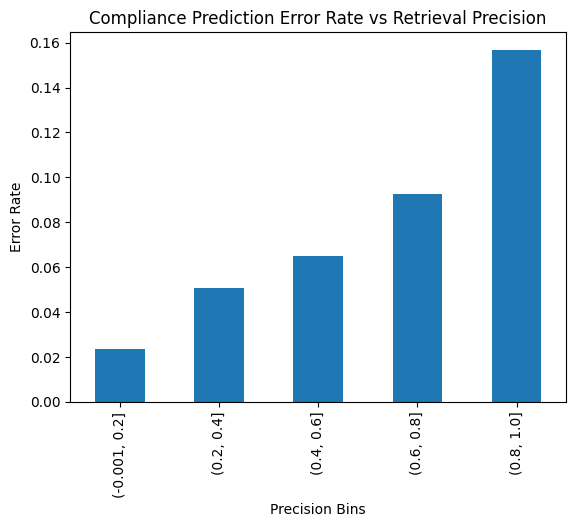

In [15]:
df["precision_bins"] = pd.cut(df["precision"], bins=5)
precision_error = df.groupby("precision_bins")["error_compliance_prediction_with_retrieval"].mean()
precision_error.plot(kind="bar")
plt.title("Compliance Prediction Error Rate vs Retrieval Precision")
plt.xlabel("Precision Bins")
plt.ylabel("Error Rate")
plt.show()

The error rate increases with retrieval precision, which is counterintuitive. To determine if this is caused by missing relevant policies (i.e., incomplete context), we'll restrict the analysis to cases where all relevant policies were successfully retrieved:

Full context cases: 687 / 1000


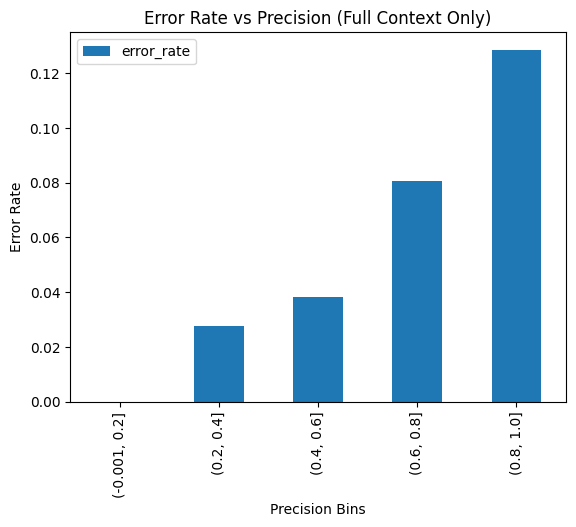

In [16]:
df_full = df[df["full_context"] == True].copy()

print(f"Full context cases: {len(df_full)} / {len(df)}")

df_full["precision_bin"] = pd.cut(df_full["precision"], bins=5)

precision_analysis = df_full.groupby("precision_bin").agg(
    error_rate=("error_compliance_prediction_with_retrieval", "mean")
)

precision_analysis.plot(kind="bar")
plt.title("Error Rate vs Precision (Full Context Only)")
plt.xlabel("Precision Bins")
plt.ylabel("Error Rate")
plt.show()

Looks like even when full context is available, the trend persists. This suggests missing policies aren't the primary driver of error.

If retrieval performance alone doesn't explain this trend, perhaps a cause can be found in the reasoning layer. Let's examine case complexity, as measured by the number of relevant policies:

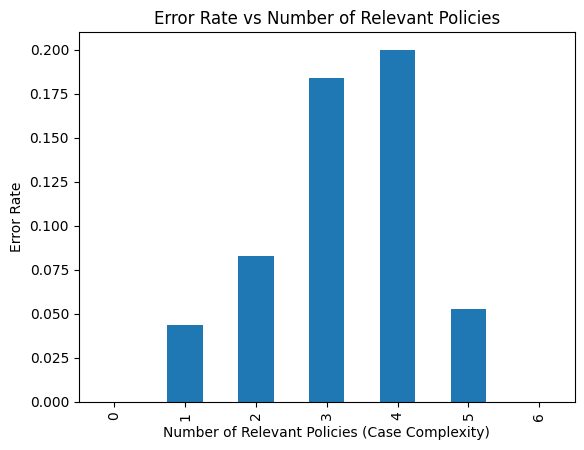

In [17]:
df["num_relevant"] = df["relevant_policies"].apply(len)

error_by_complexity = df.groupby("num_relevant")[
    "error_compliance_prediction_with_retrieval"
].mean()

error_by_complexity.plot(kind="bar")
plt.title("Error Rate vs Number of Relevant Policies")
plt.xlabel("Number of Relevant Policies (Case Complexity)")
plt.ylabel("Error Rate")
plt.show()

Yes, there seems to be a strong upward trend through the main distribution of the data, though there's a drop off at 5 and 6 relevant policies. Let's check sample sizes:

In [18]:
df.groupby("num_relevant").agg(
    error_rate=("error_compliance_prediction_with_retrieval", "mean"),
    count=("error_compliance_prediction_with_retrieval", "size")
)

,error_rate,count
num_relevant,,
0,0.000000,91
1,0.043919,296
2,0.082621,351
3,0.183784,185
4,0.200000,55
5,0.052632,19
6,0.000000,3


Given there are only 55, 19, and 3 samples available for the 4, 5, and 6 relevant policy cases, it's possible the dropoff in observed error rates is due to high variance with small sample sizes. But the increase in error rate from 0 to 4 relevant policies (larger sample sizes) suggest that multi-policy cases are more difficult for the heuristic reasoning model.

But, is the previously observed positive correlation between retrieval precision and prediction error actually being driven by case complexity? Let's dig deeper and examine how retrieval precision changes as the number of relevant policies increases:

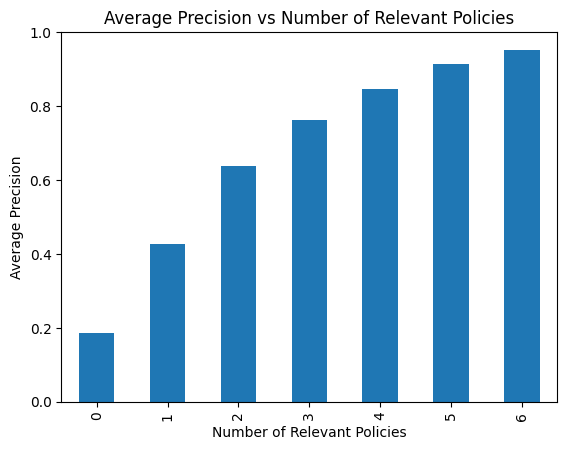

In [19]:
precision_by_complexity = df.groupby("num_relevant")["precision"].mean()

precision_by_complexity.plot(kind="bar")
plt.title("Average Precision vs Number of Relevant Policies")
plt.xlabel("Number of Relevant Policies")
plt.ylabel("Average Precision")
plt.show()

We see the average retrieval precision increases with the number of relevant policies. This suggests that the retrieval system is often able to retrieve relevant policies successfully even in more complex cases. As a result, the observed increase in prediction error with increasing precision appears to be driven by the fact that high-precision cases are often also high-complexity cases.

In other words, while retrieval quality remains relatively strong, the downstream heuristic reasoning model struggles to correctly combine multiple relevant policy signals into a final compliance decision.

At the same time, cases with larger numbers of retrieved policies sometimes benefit from additional accumulated evidence, even when some retrieved policies are noisy. This suggests that retrieval precision alone is not a reliable indicator of downstream prediction quality in this architecture.

## Section 9: Save output

In [20]:
df.to_csv("./outputs/retrieval_experiment_v1.csv", index=False)